# Analysis of time spent in sync cluster (In Progress)

To do:  
1. Also include time spent in sync state for transitions which never fall back
2. Plot - Y axis: Number of trasitions; X axis: Timesteps/time
3. Defined algo in notebook 

#### Import libraries


In [9]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc

import statistics
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#### Create objects for classes


In [2]:
reader=DataRead()
analyse = AnalysisFunc()

#### Import data

In [4]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
df_itr.shape

(40000, 200)

#### Analyse how many transitions and time spent it is according to previous algo

In [26]:
l=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [8]:
avg_sync_time=sum(l['sync'])/len(l['sync'])
print(avg_sync_time)

405.78361111111104


In [11]:
statistics.median(l['sync'])

269.26250000000005

In [16]:
l['sync'][0:3]

[109.9, 154.60000000000002, 91.85000000000001]

In [20]:
p=analyse.trans_state_time(analyse.smooth(df_itr[11]),0.05)

In [21]:
p['low_cros']

[491.3, 645.9000000000001]

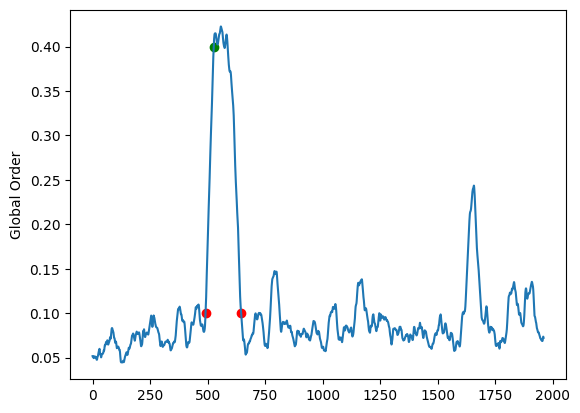

In [17]:
analyse.plot_global_synchrony(df_itr[11],0.05)

In [25]:
n3=analyse.trans_state_time(analyse.smooth(df_itr[3]),0.05)
print(n3['low_cros'])
print(n3['up_cros'])

[612.85]
[649.6500000000001]


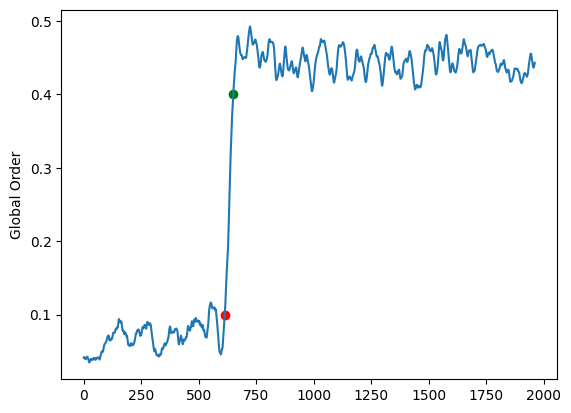

In [22]:
analyse.plot_global_synchrony(df_itr[3],0.05)

#### Let's compute the sync time as discussed

In [33]:
# call compute param to know which iterations have single transitions and which fell back or had multiple transitions

sync_time=[]
param=analyse.compute_param(df_itr,0.05)
for i in param['itr_tran']:
    df_smooth=analyse.smooth(df_itr[i])
    pm=analyse.trans_state_time(df_smooth,0.05)
    st=2000-pm['low_cros'][0]
    sync_time.append(st)

print(sync_time)
print(len(sync_time))
print(len(param['itr_tran']))

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
[195.25, 1387.15, 129.54999999999995, 1500.9, 1539.3, 1508.7, 642.6499999999999, 1439.1, 1788.95, 1592.95, 725.0999999999999, 1599.35, 1717.7, 964.8, 1770.85, 1806.2, 1609.3, 787.3999999999999, 1225.4, 1328.0, 1537.2, 1720.6, 1601.55, 944.3499

In [35]:
sync_time.sort()
print(sync_time)

[129.54999999999995, 195.25, 426.39999999999986, 541.0999999999999, 637.4499999999998, 642.6499999999999, 665.1499999999999, 687.5999999999999, 688.3999999999999, 725.0999999999999, 733.3999999999999, 750.3999999999999, 787.3999999999999, 838.3, 869.5999999999999, 891.7, 894.8, 944.3499999999999, 964.8, 1026.4, 1084.8, 1108.4499999999998, 1121.8, 1127.15, 1132.9, 1172.55, 1186.5, 1225.4, 1225.9499999999998, 1237.85, 1239.15, 1243.65, 1266.75, 1274.25, 1279.5, 1281.1999999999998, 1319.25, 1320.65, 1328.0, 1339.9, 1352.85, 1358.35, 1358.85, 1362.6, 1387.15, 1391.25, 1400.6, 1409.1, 1420.5, 1437.15, 1439.1, 1439.1999999999998, 1440.3, 1444.55, 1453.5, 1463.85, 1477.4499999999998, 1480.5, 1482.15, 1493.1, 1500.9, 1506.6, 1508.7, 1518.9, 1521.65, 1537.2, 1538.65, 1538.9, 1539.3, 1540.05, 1549.2, 1553.8, 1569.4, 1583.1, 1585.3, 1585.4, 1592.15, 1592.95, 1596.4, 1599.35, 1600.0, 1601.55, 1602.7, 1609.3, 1618.6, 1625.75, 1635.35, 1639.35, 1640.65, 1656.3, 1671.2, 1675.15, 1675.85, 1679.5, 1685